In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/drive/MyDrive/SCFP2019.csv")
df.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,6119.779308,2,75,6,12,4,2,0,...,5,3,6,3,2,10,6,6,3,3
1,1,12,4712.374912,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
2,1,13,5145.224455,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
3,1,14,5297.663412,2,75,6,12,4,2,0,...,5,2,6,2,1,10,4,4,2,2
4,1,15,4761.812371,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2


In [3]:
df.shape

(28885, 351)

In [4]:
# Force print all column names
print(list(df.columns))

['YY1', 'Y1', 'WGT', 'HHSEX', 'AGE', 'AGECL', 'EDUC', 'EDCL', 'MARRIED', 'KIDS', 'LF', 'LIFECL', 'FAMSTRUCT', 'RACECL', 'RACECL4', 'RACE', 'OCCAT1', 'OCCAT2', 'INDCAT', 'FOODHOME', 'FOODAWAY', 'FOODDELV', 'RENT', 'INCOME', 'WAGEINC', 'BUSSEFARMINC', 'INTDIVINC', 'KGINC', 'SSRETINC', 'TRANSFOTHINC', 'PENACCTWD', 'NORMINC', 'WSAVED', 'SAVED', 'SAVRES1', 'SAVRES2', 'SAVRES3', 'SAVRES4', 'SAVRES5', 'SAVRES6', 'SAVRES7', 'SAVRES8', 'SAVRES9', 'SPENDMOR', 'SPENDLESS', 'EXPENSHILO', 'LATE', 'LATE60', 'HPAYDAY', 'BNKRUPLAST5', 'KNOWL', 'YESFINRISK', 'NOFINRISK', 'CRDAPP', 'TURNDOWN', 'FEARDENIAL', 'TURNFEAR', 'FORECLLAST5', 'EMERGBORR', 'EMERGSAV', 'EMERGPSTP', 'EMERGCUT', 'HBORRFF', 'HBORRCC', 'HBORRALT', 'HBORRFIN', 'HSAVFIN', 'HSAVNFIN', 'HPSTPPAY', 'HPSTPLN', 'HPSTPOTH', 'HCUTFOOD', 'HCUTENT', 'HCUTOTH', 'FINLIT', 'BSHOPNONE', 'BSHOPGRDL', 'BSHOPMODR', 'ISHOPNONE', 'ISHOPGRDL', 'ISHOPMODR', 'BCALL', 'BMAGZNEWS', 'BMAILADTV', 'BINTERNET', 'BFRIENDWORK', 'BFINPRO', 'BSELF', 'BDONT', 'BOTHER'

In [5]:
#Credit Fearful
credit_fear = df["TURNFEAR"] == 1
df_fear = df[credit_fear]
print("df_fear shape",df_fear.shape)
df_fear.head()

df_fear shape (4623, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


In [6]:
df["AGECL"].unique()

array([6, 3, 1, 5, 4, 2])

In [7]:
agecl_dict = {
    1: "Under 35",
    2: "35-44",
    3: "45-54",
    4: "55-64",
    5: "65-74",
    6: "75 or Older",
}

age_groups = df_fear['AGECL'].replace(agecl_dict)
print(age_groups.unique())

['45-54' '65-74' 'Under 35' '35-44' '55-64' '75 or Older']


In [8]:
# Credit fear among age-groups
age_group_counts = age_groups.value_counts()

fig = px.bar(data_frame=age_group_counts)

fig.show()



In [9]:
fig = px.histogram(df_fear, x="AGE",nbins=10)
fig.show()

In [10]:
df_fear["RACE"].unique()

array([1, 3, 2, 5])

In [11]:
# Exploring race distribution
race_dict = {
    1: "White/Non-Hispanic",
    2: "Black/African-American",
    3: "Hispanic",
    5: "Other",
}

race_groups = df_fear["RACE"].replace(race_dict)

print(race_groups.unique())



['White/Non-Hispanic' 'Hispanic' 'Black/African-American' 'Other']


In [12]:
fig = px.bar(data_frame=race_groups.value_counts())

fig.show()

In [13]:
# Mapping of percentile code into percentile income ranges
inccat_dict = {
    1: "0-20",
    2: "21-39.9",
    3: "40-59.9",
    4: "60-79.9",
    5: "80-89.9",
    6: "90-100",
}

df_inccat = (
    df["INCCAT"]
    .replace(inccat_dict)
    .groupby(df["TURNFEAR"])
    .value_counts(normalize=True)
    .rename("frequency")
    .reset_index()
    )
df_inccat.head()

,TURNFEAR,INCCAT,frequency
0,0,90-100,0.297296
1,0,60-79.9,0.174841
2,0,40-59.9,0.143146
3,0,0-20,0.140343
4,0,21-39.9,0.135933


In [21]:
fig = px.bar(
    df_inccat,
    x="INCCAT",
    y="frequency",
    color="TURNFEAR",
    barmode="group"
)

fig.show()

In [34]:
df["HSTOCKS"].value_counts()

,count
HSTOCKS,
0,22033
1,6852


In [35]:
px.bar(df["HSTOCKS"].value_counts())

In [38]:
asset_house_corr = df["ASSET"].corr(df["HOUSES"])

print(asset_house_corr)

0.5198273544779252


In [39]:
debt_net_corr = df['ASSET'].corr(df["NETWORTH"])

print(debt_net_corr)

0.999052907023909


In [40]:
df["EDUC"].unique()

array([12,  8, 13, 10,  9, 11, 14,  2,  6,  7,  3,  5,  1,  4, -1])

In [42]:
cols = ["ASSET", "HOUSES", "INCOME", "DEBT", "EDUC"]

corr_col = df[cols].corr()

fig = px.imshow(corr_col)

fig.show()

In [43]:
df_educ = (
    df["EDUC"]
    .groupby(df["TURNFEAR"])
    .value_counts(normalize=True)
    .rename("frequency")
    .reset_index()
)
df_educ.head()

,TURNFEAR,EDUC,frequency
0,0,12,0.257481
1,0,8,0.192029
2,0,13,0.149823
3,0,9,0.129833
4,0,14,0.096117


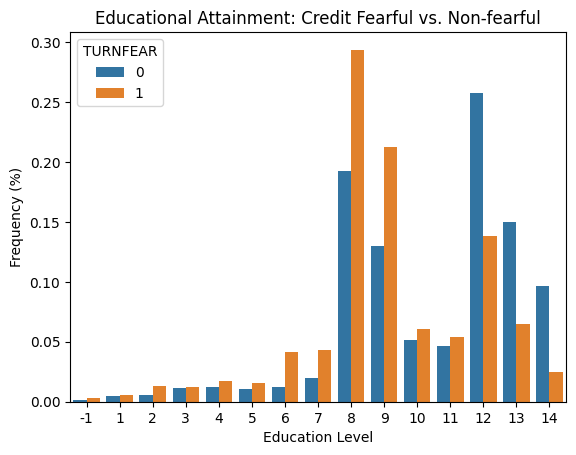

In [44]:
sns.barplot(x="EDUC", y="frequency", hue="TURNFEAR", data=df_educ) # x="EDUC", y="frequency", hue="TURNFEAR", data=df_educ
plt.xlabel("Education Level")
plt.ylabel("Frequency (%)")
plt.title("Educational Attainment: Credit Fearful vs. Non-fearful");

In [47]:
df["MARRIED"].unique()

df_married = (
    df["MARRIED"]
    .groupby(df["TURNFEAR"])
    .value_counts(normalize=True)
    .rename("frequency")
    .reset_index()
)

In [48]:
fig = px.bar(df_married, x="MARRIED", y="frequency", color="TURNFEAR", barmode="group")

fig.show()

In [51]:
fig = px.scatter(df,x="DEBT", y="ASSET")
fig.show()

In [52]:
fig= px.scatter(df_fear, x="DEBT", y="ASSET")
fig.show()